# Week 7 Lecture Notes: Lindholm Chapter 6 - Neural Networks and Deep Learning

## Contents

- [Scope for Week 7](#scope-for-week-7)
- [Learning goals for this notebook](#learning-goals-for-this-notebook)
- [Chapter 6 summary](#chapter-6-summary)
  - [From generalised linear models to neural network units](#from-generalised-linear-models-to-neural-network-units)
  - [Two-layer neural networks and hidden units](#two-layer-neural-networks-and-hidden-units)
  - [Deep networks and vectorised notation](#deep-networks-and-vectorised-notation)
  - [Neural networks for classification](#neural-networks-for-classification)
  - [Training objective and stochastic gradient descent](#training-objective-and-stochastic-gradient-descent)
  - [Backpropagation](#backpropagation)
  - [Initialisation and common failure modes](#initialisation-and-common-failure-modes)
  - [What this notebook deliberately defers to Week 8](#what-this-notebook-deliberately-defers-to-week-8)
- [Exam-oriented takeaways](#exam-oriented-takeaways)
- [Past exam questions (2023-2025)](#past-exam-questions-2023-2025)
- [Toy example 1: activation functions and derivatives](#toy-example-1-activation-functions-and-derivatives)
- [Toy example 2: forward pass and softmax on a tiny MLP](#toy-example-2-forward-pass-and-softmax-on-a-tiny-mlp)
- [Toy example 3: training XOR with backpropagation](#toy-example-3-training-xor-with-backpropagation)
- [Week 7 wrap-up](#week-7-wrap-up)
- [Sources used](#sources-used)

## Scope for Week 7

- Topic: neural networks and deep learning.
- Important concepts: hidden units, activation functions, multilayer perceptrons, logits, softmax outputs, mini-batches, and backpropagation.
- Algorithms and methods: fully connected feedforward neural networks, stochastic gradient descent, and backpropagation.
- Reading: [Lindholm (2022), Chapter 6](../../references/main-text-book-machine-learning-lindholm-2022.pdf), with this notebook focusing on Sections 6.1-6.2 because the course summary places convolutional neural networks in Week 8.
- Prac alignment: Week 7 practical covers multilayer perceptron neural networks. Demos continue this week, and the course summary also flags the optional assignment draft due.
- Source note: these base notes are grounded in the [Course Summary Table](../../references/CourseSummaryTable_v1_26.pdf), Lindholm Chapter 6, and the indexed exam materials. The local [MATLAB notes](../../references/lecture_notes_matlab_2026_v2.pdf) cover related material, but they are supporting context rather than the primary structure here.

## Learning goals for this notebook

1. Write down the forward equations for a fully connected neural network, including the meaning and dimensions of the weight matrices, hidden units, logits, and softmax outputs.
2. Explain how neural networks are trained in Chapter 6: average loss as the objective, mini-batch gradient descent as the optimiser, and backpropagation as the gradient-computation routine.
3. Build exam-ready intuition for common failure modes such as poor learning rates, saturated activations, dead ReLUs, shape mistakes, and overfitting.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 4702
random.seed(SEED)
np.random.seed(SEED)
plt.rcParams["figure.dpi"] = 120

print(f"Seed set to {SEED}")

Seed set to 4702


## Chapter 6 summary

Week 7 is the first half of the course's neural-network material. The main model in scope is the fully connected feedforward network, also called a multilayer perceptron (MLP). For exam preparation, keep the standard frame in mind:

- **Objective:** represent a non-linear input-output mapping and, for classification, model class probabilities.
- **Optimisation:** minimise an average training loss with gradient-based updates.
- **Failure modes:** poor learning rates, bad initialisation, saturated or inactive units, and overfitting due to too much flexibility.

### From generalised linear models to neural network units

Lindholm opens Chapter 6 by writing a neural network as a non-linear parametric model

$$
\hat{y} = f_{\theta}(x_1, \ldots, x_p). \qquad (6.1)
$$

The starting point is still familiar linear regression:

$$
\hat{y} = W_1 x_1 + W_2 x_2 + \cdots + W_p x_p + b. \qquad (6.2)
$$

The neural-network step is to apply a non-linear **activation function** to an affine combination of the inputs:

$$
\hat{y} = h(W_1 x_1 + W_2 x_2 + \cdots + W_p x_p + b). \qquad (6.3)
$$

This single unit is the basic building block of the chapter.

Two activation functions are explicit textbook defaults:

$$
\text{Logistic: } h(z) = \frac{1}{1 + e^{-z}}, \qquad
\text{ReLU: } h(z) = \max(0, z).
$$

Why this matters:

- without a non-linearity, stacking layers would collapse back to one large linear map;
- the logistic activation is smooth and bounded, which makes it easy to interpret but susceptible to saturation;
- the ReLU is simple and usually easier to optimise in deep models, but a unit can become inactive if it stays in the negative regime.

Minimal exam statement:

- an artificial neuron is just an affine map followed by a non-linear activation.

### Two-layer neural networks and hidden units

To make the model more flexible, Lindholm introduces several parallel activated regression units. For hidden unit $k$,

$$
q_k = h(W_{k1}x_1 + W_{k2}x_2 + \cdots + W_{kp}x_p + b_k), \qquad k=1,\ldots,U. \qquad (6.4)
$$

These hidden units are then combined by another affine map:

$$
\hat{y} = W_1^{(2)} q_1 + W_2^{(2)} q_2 + \cdots + W_U^{(2)} q_U + b^{(2)}. \qquad (6.5)
$$

In matrix form, the two-layer neural network is

$$
q = h(W^{(1)}x + b^{(1)}), \qquad \hat{y} = W^{(2)}q + b^{(2)}. \qquad (6.8)
$$

Important interpretation:

- $q$ is a vector of **hidden units**;
- the hidden units are not observed labels or features from the dataset, but learned intermediate representations;
- $U$ is a hyperparameter controlling model flexibility.

This is the cleanest place to connect neural networks back to Week 4:

- linear regression: no hidden layer, identity output;
- logistic regression / softmax regression: still one layer, but with output activation;
- MLP: add hidden units and non-linear activations between the input and the output.

Chapter 6's MNIST example is a good exam reminder about parameter counting. If the input has $p=784$ features, the output has $M=10$ classes, and the hidden layer has $U=200$ units, then a one-hidden-layer classifier needs

$$
784 \cdot 200 + 200 + 200 \cdot 10 + 10 = 159010
$$

trainable parameters.

### Deep networks and vectorised notation

The deep-network generalisation just stacks the same pattern:

$$
q^{(l)} = h(W^{(l)} q^{(l-1)} + b^{(l)}), \qquad l=1,\ldots,L-1, \qquad
\hat{y} = W^{(L)} q^{(L-1)} + b^{(L)}. \qquad (6.11)
$$

The dimensions matter:

- $W^{(1)} \in \mathbb{R}^{U_1 \times p}$,
- $W^{(l)} \in \mathbb{R}^{U_l \times U_{l-1}}$ for hidden layers,
- $W^{(L)} \in \mathbb{R}^{1 \times U_{L-1}}$ for scalar regression output,
- $W^{(L)} \in \mathbb{R}^{M \times U_{L-1}}$ for $M$-class classification.

The phrase **fully connected feedforward** means:

- every unit in one layer connects to every unit in the next layer;
- information moves strictly from input to output, not in recurrent loops;
- the network is still just a composition of simple affine maps and pointwise non-linearities.

For implementation, Chapter 6 vectorises across a mini-batch of data points. If the rows of $X$ are data points, then the first hidden layer can be evaluated as

$$
Q = h(XW^{(1)T} + b^{(1)T}). \qquad (6.14a)
$$

This is why the code you write later uses matrix multiplications instead of looping over one data point at a time.

### Neural networks for classification

For classification, the last affine map produces **logits**:

$$
z = W^{(L)} q^{(L-1)} + b^{(L)}. \qquad (6.16c)
$$

These logits are turned into class probabilities by the softmax:

$$
g = \text{softmax}(z), \qquad
g_m = \frac{e^{z_m}}{\sum_{j=1}^{M} e^{z_j}}. \qquad (6.15), (6.16d)
$$

Key meaning:

- $z_m$ is a score for class $m$ before normalisation;
- $g_m$ is the model for $p(y=m \mid x)$;
- softmax adds no new trainable parameters, it only transforms the final scores.

The standard multiclass training loss is cross-entropy:

$$
L(x, y, \theta) = -\log g_y = -z_y + \log \sum_{j=1}^{M} e^{z_j}. \qquad (6.20)
$$

This pairing matters:

- softmax gives a valid probability vector;
- cross-entropy rewards high probability on the correct class;
- together they lead to a clean gradient at the output layer.

Failure modes to remember:

- logits are not probabilities until softmax is applied;
- computing softmax naively can overflow numerically when logits are large;
- using the wrong output activation for the task usually breaks both interpretation and optimisation.

### Training objective and stochastic gradient descent

All weight matrices and offset vectors are collected into one parameter vector $\theta$:

$$
\theta = \left[\text{vec}(W^{(1)})^T \; b^{(1)T} \; \cdots \; \text{vec}(W^{(L)})^T \; b^{(L)T}\right]^T. \qquad (6.17)
$$

Training is written as

$$
\hat{\theta} = \arg\min_{\theta} J(\theta),
\qquad
J(\theta) = \frac{1}{n}\sum_{i=1}^{n} L(x_i, y_i, \theta). \qquad (6.18)
$$

So the Week 7 framing is:

- **Objective:** minimise average loss on the training data as a proxy for good generalisation;
- **Optimisation:** use iterative gradient-based updates rather than a closed-form solution;
- **Failure modes:** too-small learning rates are slow, too-large learning rates overshoot or diverge, and the non-convex objective can trap the optimiser in poor regions.

The chapter uses the standard gradient update

$$
\theta^{t+1} \leftarrow \theta^t - \gamma \nabla_{\theta} J(\theta^t), \qquad (6.21)
$$

where $\gamma$ is the learning rate.

Why stochastic / mini-batch gradient descent appears:

1. deep-learning datasets often have very large $n$, so the exact full-dataset gradient is too expensive to compute every step;
2. the number of parameters can also be very large, so the gradient computation itself must be organised carefully;
3. mini-batches provide a cheaper gradient estimate and fit naturally with array-based implementations.

Vocabulary you should be able to say quickly:

- **mini-batch size** $n_b$: the number of training examples in one gradient estimate;
- **epoch**: one full pass through the training set;
- **learning rate** $\gamma$: the step size in parameter space.

### Backpropagation

Backpropagation is not the whole training algorithm. It is the efficient procedure for computing the cost function and all of the parameter gradients needed by gradient descent.

For one data point, the forward pass is

$$
q^{(0)} = x, \qquad
z^{(l)} = W^{(l)}q^{(l-1)} + b^{(l)}, \qquad
q^{(l)} = h(z^{(l)}) \text{ for } l=1,\ldots,L-1. \qquad (6.24a-c)
$$

For multiclass classification, the output-layer contribution to the loss gradient is

$$
d z_j^{(L)}
= -I\{y=j\} + \frac{e^{z_j^{(L)}}}{\sum_{k=1}^{M} e^{z_k^{(L)}}}
= g_j - I\{y=j\}. \qquad (6.26b)
$$

The backward recursion is then

$$
d z^{(l)} = d q^{(l)} \odot h'(z^{(l)}), \qquad
d q^{(l-1)} = W^{(l)T} d z^{(l)}, \qquad (6.27a-b)
$$

followed by the parameter gradients

$$
d W^{(l)} = d z^{(l)} q^{(l-1)T}, \qquad
d b^{(l)} = d z^{(l)}. \qquad (6.27c-d)
$$

For a mini-batch, Algorithm 6.1 uses the same logic but stacked in matrices. This is why the 2024 exam asks directly about:

- what $Q^{(l)}$ means (the layer-$l$ activations for the current mini-batch),
- what $n_b$ means (the mini-batch size),
- and how $\nabla_{\theta}J(\theta)$ is used in the update.

The main exam idea is simple:

- forward propagation computes predictions and the loss;
- backward propagation uses the chain rule to reuse partial derivatives efficiently;
- the resulting gradients are used to update each layer's weights and offsets.

### Initialisation and common failure modes

Unlike the convex objectives from earlier weeks, neural-network training is usually **non-convex**. That makes the initial parameter choice matter.

Lindholm's practical guidance is:

- initialise the weights to small random values so hidden units do not all learn the same thing;
- with ReLU activations, it is common to initialise offsets to a small positive value so the units begin in the non-negative region;
- track validation behaviour, because lower training loss alone does not guarantee better generalisation.

Example 6.2 in the chapter is useful as a sanity check:

- the softmax logistic-regression model on MNIST reaches roughly 8% validation misclassification;
- adding one hidden layer with 200 ReLU units drops validation misclassification to roughly 2%;
- however, the gap between training and validation performance shows that overfitting is already visible.

Common Week 7 failure modes:

1. **Shape errors:** wrong matrix dimensions or transposes in the forward or backward pass.
2. **Activation mismatch:** forgetting that the last layer for multiclass classification uses logits plus softmax, not another hidden-layer activation.
3. **Learning-rate problems:** very slow progress, oscillation, or divergence.
4. **Vanishing gradients:** especially with saturating activations like the logistic sigmoid.
5. **Dead ReLUs:** units stuck with negative pre-activations and zero gradient.
6. **Overfitting:** too many hidden units or too much training without enough regularisation or validation control.

### What this notebook deliberately defers to Week 8

The course summary assigns Week 8 to the Chapter 6 material on convolutional neural networks. So this notebook stops before the details of:

- convolutional layers,
- parameter sharing and sparse interactions,
- strides and pooling,
- dropout as a neural-network regularisation method.

You should still recognise these as part of the same chapter, because later exam questions may connect them back to Week 7 ideas such as hidden units, weight counts, and learning dynamics.

## Exam-oriented takeaways

The high-value Week 7 ideas are:

1. A feedforward neural network is a composition of affine maps and non-linear activations.
2. Hidden units are learned intermediate features; the number of hidden units and layers are hyperparameters.
3. For classification, the final layer produces logits, softmax converts them into probabilities, and cross-entropy is the default loss.
4. Backpropagation is the chain-rule algorithm that computes gradients efficiently for every layer.
5. Mini-batches make training cheaper; the learning rate controls how aggressive the updates are.
6. Neural networks are flexible and powerful, but that same flexibility creates risks of non-convex optimisation difficulties and overfitting.

Fast exam checklist:

- Can I write the output equation for a network with one hidden layer?
- Can I state the shape of each weight matrix from the layer sizes?
- Can I explain what $M$, $h(\cdot)$, $Q^{(l)}$, and $n_b$ mean?
- Can I explain why backpropagation is needed instead of a closed-form solution?
- Can I say what happens when the learning rate is too small or too large?

## Past exam questions (2023-2025)

These were selected using [exam_questions_2023_2025_by_week.csv](../../references/exam_questions_2023_2025_by_week.csv) and copied from [COMP4702_exams_2023_2025.md](../../references/COMP4702_exams_2023_2025.md).

### 2023 Part A, Question 2

Source: [2023 exam PDF](../../references/2023_COMP4702_exam.pdf)

- Which of the following is NOT a commonly used activation function in neural networks?
- The extracted markdown is slightly malformed for the formulas, but the option names are clear: logistic, ReLU, linear, and `sinh`.

Revision note: Lindholm Chapter 6 explicitly introduces logistic and ReLU. For this course, those are the activation names to recognise immediately. Linear outputs are useful at regression outputs, but they do not create hidden-layer non-linearity.

### 2023 Part B, Question 5

Source: [2023 exam PDF](../../references/2023_COMP4702_exam.pdf)

- A fully-connected feedforward neural network can be described mathematically as:

$$
q^{(1)} = h(W^{(1)}x + b^{(1)}), \quad \ldots, \quad q^{(L-1)} = h(W^{(L-1)}q^{(L-2)} + b^{(L-1)}),
$$

$$
z = W^{(L)}q^{(L-1)} + b^{(L)}, \qquad g = \text{softmax}(z).
$$

- (a) How many layers of weights does this network have?
- (b) What does $M$ represent?
- (c) What does $h()$ represent?
- (d) Consider a fully-connected feedforward network to be trained on the MNIST dataset, where each input is a `28 x 28` image. The network is to have two hidden layers, each with 100 units. What is the size (`rows x columns`) of `W^(1)`, `b^(2)`, and `W^(3)`?

Revision note: this is the cleanest Week 7 dimensions-and-notation question. Practise it until you can answer without drawing the whole network.

### 2024 Part B, Question 3

Source: [2024 exam PDF](../../references/2024_COMP4702_exam.pdf)

- Figure 3 is taken from the course textbook (Algorithm 6.1).
- (a) In Algorithm 6.1, what does $Q^{(l)}$ represent?
- (b) In Algorithm 6.1, what does $n_b$ represent?
- (c) In Algorithm 6.1, which line calculates the cross-entropy cost function?
- (d) To train a neural network, Algorithm 6.1 is typically used as a subroutine of (stochastic) gradient descent. Explain how the information from Algorithm 6.1 (specifically, $\nabla_{\theta} J(\theta)$) is used to update the weights of the network.

Revision note: know the algorithm flow in words: forward pass, cost evaluation, backward pass, then gradient-based parameter update.

### 2025 Part B, Question 6

Source: [2025 exam PDF](../../references/2025_COMP4702_exam.pdf)

- Figure 5 (from the textbook) shows an illustration of gradient descent when different learning rate values are used.
- Using the example of training a feedforward neural network and Figure 5, explain briefly what the objective of gradient descent is and why it can be challenging to find a suitable value for the learning rate hyperparameter.

Revision note: your answer should mention minimising the training cost, slow progress when $\gamma$ is too small, and overshooting / instability when $\gamma$ is too large.

### 2025 Part B, Question 7

Source: [2025 exam PDF](../../references/2025_COMP4702_exam.pdf)

- Figure 6 (from the textbook) shows a diagram of a feed-forward neural network with a single hidden layer.
- Using the notation given in Figure 6, write down an equation for the output of the neural network.

Revision note: the standard one-hidden-layer answer is

$$
\hat{y} = W^{(2)} h(W^{(1)}x + b^{(1)}) + b^{(2)}
$$

or the softmax version if the problem is multiclass classification.

### 2024 Part B, Question 5 (secondary relevance)

Source: [2024 exam PDF](../../references/2024_COMP4702_exam.pdf)

- Figure 5 is taken from a machine learning textbook and shows some experimental results comparing neural networks trained with and without weight decay.
- (a) What do the results in Figure 5 show regarding the effect of weight decay?
- (b) What do the results in Figure 5 show regarding the effect of varying the number of hidden units?

Revision note: this question bridges Week 6 and Week 7. Weight decay is just L2 regularisation in neural-network language, and the number of hidden units is a flexibility hyperparameter.

## Toy example 1: activation functions and derivatives

This example makes the two textbook activation functions visible, together with their derivatives.

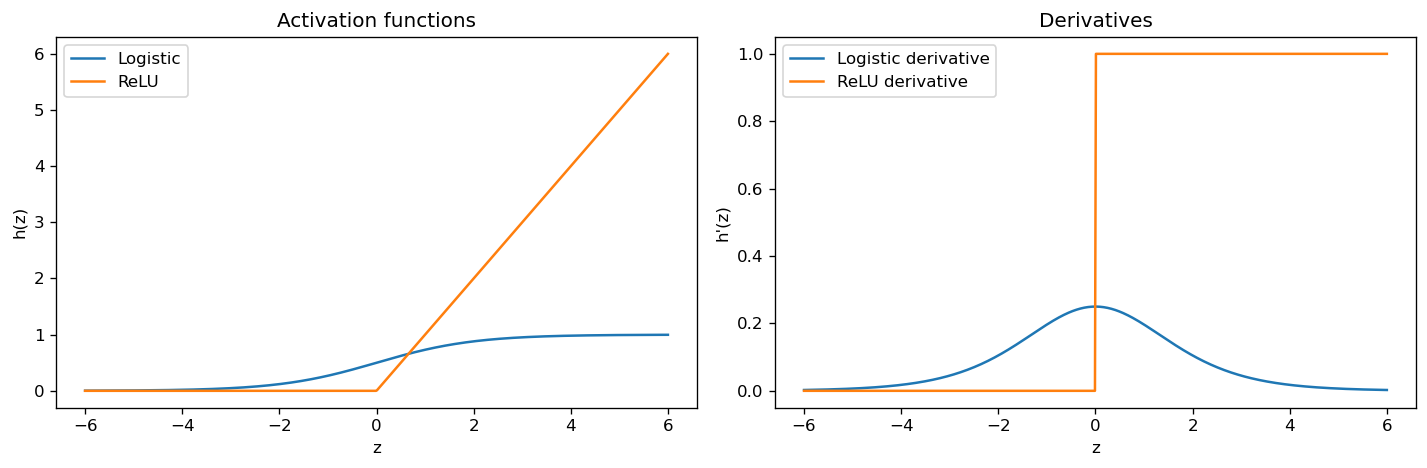

probe z values      : [-6.  0.  6.]
logistic(z)         : [0.0025 0.5    0.9975]
logistic_prime(z)   : [0.0025 0.25   0.0025]
relu(z)             : [0. 0. 6.]
relu_prime(z)       : [0. 0. 1.]


In [2]:
def logistic(z):
    return 1.0 / (1.0 + np.exp(-z))


def logistic_prime(z):
    s = logistic(z)
    return s * (1.0 - s)


def relu(z):
    return np.maximum(0.0, z)


def relu_prime(z):
    return (z > 0.0).astype(float)


z = np.linspace(-6.0, 6.0, 600)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, logistic(z), label="Logistic")
axes[0].plot(z, relu(z), label="ReLU")
axes[0].set_title("Activation functions")
axes[0].set_xlabel("z")
axes[0].set_ylabel("h(z)")
axes[0].legend()

axes[1].plot(z, logistic_prime(z), label="Logistic derivative")
axes[1].plot(z, relu_prime(z), label="ReLU derivative")
axes[1].set_title("Derivatives")
axes[1].set_xlabel("z")
axes[1].set_ylabel("h'(z)")
axes[1].legend()

plt.tight_layout()
plt.show()

probe_points = np.array([-6.0, 0.0, 6.0])
print("probe z values      :", probe_points)
print("logistic(z)         :", np.round(logistic(probe_points), 4))
print("logistic_prime(z)   :", np.round(logistic_prime(probe_points), 4))
print("relu(z)             :", np.round(relu(probe_points), 4))
print("relu_prime(z)       :", np.round(relu_prime(probe_points), 4))

What to notice:

- the logistic derivative is largest near zero and tiny in the saturated tails;
- the ReLU derivative is 1 on the positive side and 0 on the negative side;
- this is the simplest visual explanation for vanishing-gradient risk with sigmoids and dead-unit risk with ReLUs.

## Toy example 2: forward pass and softmax on a tiny MLP

This example tracks the matrix shapes and intermediate quantities for one small classification network.

In [3]:
def softmax(z):
    shifted = z - np.max(z)
    exp_z = np.exp(shifted)
    return exp_z / exp_z.sum()


x = np.array([0.2, -1.0, 0.7])

W1 = np.array([
    [1.0, -0.5, 0.8],
    [-0.4, 0.9, 0.2],
    [0.3, -1.2, 0.5],
    [0.7, 0.1, -0.6],
])
b1 = np.array([0.1, -0.2, 0.0, 0.3])

W2 = np.array([
    [1.2, -0.7, 0.3, 0.5],
    [-0.6, 0.4, 0.9, -0.3],
    [0.2, 0.8, -0.5, 0.1],
])
b2 = np.array([0.1, -0.1, 0.2])

z1 = W1 @ x + b1
q1 = relu(z1)
z2 = W2 @ q1 + b2
g = softmax(z2)

print("x shape :", x.shape)
print("W1 shape:", W1.shape, "b1 shape:", b1.shape)
print("W2 shape:", W2.shape, "b2 shape:", b2.shape)
print()
print("hidden pre-activations z1 =", np.round(z1, 4))
print("hidden activations q1     =", np.round(q1, 4))
print("output logits z2          =", np.round(z2, 4))
print("softmax probabilities g   =", np.round(g, 4))
print("sum(g)                    =", round(float(g.sum()), 6))
print("predicted class index     =", int(np.argmax(g)))

x shape : (3,)
W1 shape: (4, 3) b1 shape: (4,)
W2 shape: (3, 4) b2 shape: (3,)

hidden pre-activations z1 = [ 1.36 -1.04  1.61 -0.08]
hidden activations q1     = [1.36 0.   1.61 0.  ]
output logits z2          = [ 2.215  0.533 -0.333]
softmax probabilities g   = [0.791  0.1471 0.0619]
sum(g)                    = 1.0
predicted class index     = 0


Interpretation:

- `z1` is the affine input to the hidden layer;
- `q1` is the hidden representation after the activation;
- `z2` is the vector of logits;
- `g` is the probability vector used by the cross-entropy loss.

## Toy example 3: training XOR with backpropagation

This is a very small, fully connected classifier trained from scratch. The point is not that XOR is realistic; the point is that it makes the forward pass, cross-entropy loss, and backpropagation updates completely explicit.

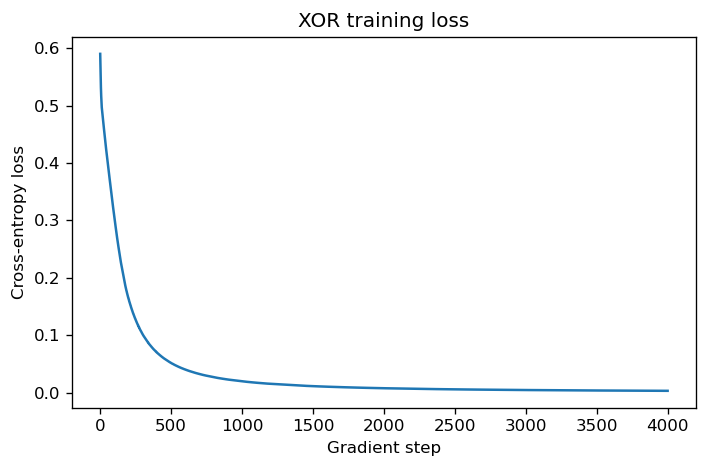

initial loss = 0.5904
final loss   = 0.0029
predictions  = [0, 1, 1, 0]
true labels  = [0, 1, 1, 0]
accuracy     = 1.000
probabilities:
[[0.9939 0.0061]
 [0.0021 0.9979]
 [0.0022 0.9978]
 [0.9987 0.0013]]


In [4]:
X = np.array([
    [0.0, 0.0],
    [0.0, 1.0],
    [1.0, 0.0],
    [1.0, 1.0],
])
y = np.array([0, 1, 1, 0])
Y = np.eye(2)[y]

rng = np.random.default_rng(SEED)
hidden_units = 4

# Book-style shapes: W^(1) is U x p and W^(2) is M x U.
W1 = rng.normal(scale=np.sqrt(2.0 / X.shape[1]), size=(hidden_units, X.shape[1]))
b1 = np.full(hidden_units, 0.1)
W2 = rng.normal(scale=np.sqrt(2.0 / hidden_units), size=(2, hidden_units))
b2 = np.zeros(2)


def softmax_batch(Z):
    shifted = Z - Z.max(axis=1, keepdims=True)
    exp_Z = np.exp(shifted)
    return exp_Z / exp_Z.sum(axis=1, keepdims=True)


learning_rate = 0.05
steps = 4000
loss_history = []

for _ in range(steps):
    Z1 = X @ W1.T + b1
    Q1 = relu(Z1)
    Z2 = Q1 @ W2.T + b2
    G = softmax_batch(Z2)

    loss = -np.mean(np.log(G[np.arange(len(y)), y] + 1e-12))
    loss_history.append(loss)

    dZ2 = (G - Y) / len(X)
    dW2 = dZ2.T @ Q1
    db2 = dZ2.sum(axis=0)

    dQ1 = dZ2 @ W2
    dZ1 = dQ1 * relu_prime(Z1)
    dW1 = dZ1.T @ X
    db1 = dZ1.sum(axis=0)

    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

Z1 = X @ W1.T + b1
Q1 = relu(Z1)
Z2 = Q1 @ W2.T + b2
G = softmax_batch(Z2)
predictions = G.argmax(axis=1)
accuracy = np.mean(predictions == y)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(loss_history)
ax.set_title("XOR training loss")
ax.set_xlabel("Gradient step")
ax.set_ylabel("Cross-entropy loss")
plt.tight_layout()
plt.show()

print(f"initial loss = {loss_history[0]:.4f}")
print(f"final loss   = {loss_history[-1]:.4f}")
print("predictions  =", predictions.tolist())
print("true labels  =", y.tolist())
print(f"accuracy     = {accuracy:.3f}")
print("probabilities:")
print(np.round(G, 4))

What to look for:

- the loss should decrease substantially over training;
- the hidden layer makes the XOR problem linearly separable in the learned representation;
- the updates use exactly the Week 7 chain-rule structure: output gradient, hidden gradient, then weight and bias gradients for each layer.

## Week 7 wrap-up

What to remember:

1. A neural network is not mysterious mathematically: it is repeated affine maps plus element-wise non-linearities.
2. The moment you add a hidden layer, shape-tracking and notation become essential exam skills.
3. For multiclass classification, the standard pair is logits plus softmax, trained with cross-entropy.
4. Backpropagation computes gradients efficiently; stochastic gradient descent uses those gradients to update the parameters.
5. The main practical risks are shape errors, poor learning rates, activation-related gradient problems, and overfitting.
6. Week 8 will reuse all of this machinery, but with convolutional layers instead of only dense hidden layers.

## Sources used

1. [Course Summary Table, Semester 1 2026](../../references/CourseSummaryTable_v1_26.pdf)
2. [Lindholm et al. (2022), main textbook, Chapter 6](../../references/main-text-book-machine-learning-lindholm-2022.pdf)
3. [Exam question index by week](../../references/exam_questions_2023_2025_by_week.csv)
4. [Extracted COMP4702 exam text (2023-2025)](../../references/COMP4702_exams_2023_2025.md)
5. [2023 COMP4702 exam PDF](../../references/2023_COMP4702_exam.pdf)
6. [2024 COMP4702 exam PDF](../../references/2024_COMP4702_exam.pdf)
7. [2025 COMP4702 exam PDF](../../references/2025_COMP4702_exam.pdf)